# Vehicle Insurance Claim Fraud Detection

## Step 1: Problem Statement

Insurance fraud poses a significant risk to insurance companies, resulting in increased claim costs and operational inefficiencies. Detecting fraudulent claims early is crucial to minimize losses and optimize investigation efforts.

The objective of this project is to apply machine learning techniques to identify fraudulent vehicle insurance claims using historical data.

## Problem Formulation
- **Type:** Supervised Machine Learning
- **Task:** Binary Classification
- **Target Variable:**
  - `1` → Fraudulent claim
  - `0` → Genuine claim

## Evaluation Strategy
Given the imbalanced nature of fraud detection datasets, the primary evaluation focus will be on:
- Recall
- Precision
- F1-Score
- ROC-AUC

Accuracy alone is not considered a reliable performance measure for this problem.


## Step 2: Data Loading and Understanding

In this step, the raw vehicle insurance claim dataset is loaded and analyzed to understand its structure, feature composition, and data quality. No preprocessing or feature engineering is performed at this stage.

In [4]:
import pandas as pd
import numpy as np

# Load dataset
data_path = "../data/raw/vehicle_claim_fraud.csv"
df = pd.read_csv(data_path)

# Basic inspection
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


# Dataset shape

In [5]:
# Dataset shape
df.shape

(15420, 33)

# Dataset information

In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

# List of columns

In [7]:
# List of columns
df.columns.tolist()

['Month',
 'WeekOfMonth',
 'DayOfWeek',
 'Make',
 'AccidentArea',
 'DayOfWeekClaimed',
 'MonthClaimed',
 'WeekOfMonthClaimed',
 'Sex',
 'MaritalStatus',
 'Age',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'VehiclePrice',
 'FraudFound_P',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Days_Policy_Accident',
 'Days_Policy_Claim',
 'PastNumberOfClaims',
 'AgeOfVehicle',
 'AgeOfPolicyHolder',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'NumberOfSuppliments',
 'AddressChange_Claim',
 'NumberOfCars',
 'Year',
 'BasePolicy']

# Identify Feature Types

In [8]:
# Separate numerical and categorical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Numerical Features: 9
Categorical Features: 24


# Target Variable Identification

In [9]:
# Target variable distribution
df['FraudFound_P'].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

## Dataset Overview and Target Variable Analysis

In this step, the vehicle insurance claim dataset was analyzed to understand its structure, feature composition, and target variable distribution before performing any preprocessing or modeling.

### Dataset Summary
- **Total records:** 15,420
- **Total features:** 33
- **Target variable:** `FraudFound_P`
  - `0` → Genuine claim
  - `1` → Fraudulent claim

### Target Variable Distribution
The distribution of the target variable is as follows:

- **Genuine claims (0):** 14,497  
- **Fraudulent claims (1):** 923  

Fraudulent claims constitute approximately **6%** of the dataset, while genuine claims make up about **94%**.

### Class Imbalance Observation
The dataset is **highly imbalanced**, which is a common characteristic of real-world fraud detection problems. This imbalance can cause machine learning models to be biased toward the majority class (genuine claims) if not handled carefully.

### Implications of Class Imbalance
- **Accuracy alone is not a reliable performance metric**, as a model predicting all claims as genuine would still achieve high accuracy.
- Greater emphasis must be placed on:
  - **Recall** → to capture as many fraudulent claims as possible
  - **Precision** → to avoid excessive false fraud alerts
  - **F1-score and ROC-AUC** for balanced evaluation

Handling this imbalance appropriately will be addressed in later stages of model training and evaluation.

---

### Key Data Understanding Observations
- The dataset contains **no missing values**, simplifying preprocessing steps.
- The **majority of features are categorical**, requiring careful encoding strategies.
- Some numerical columns, such as **`PolicyNumber` and `RepNumber`**, behave like identifiers and may not contribute meaningfully to fraud prediction.
- Fraud detection is inherently a **class-imbalanced problem**, which influences model selection and evaluation strategy.
- Several features represent **claim investigation signals** (e.g., police report filed, witness present), which may strongly correlate with fraudulent behavior and will be closely examined during exploratory data analysis.

These observations guide the exploratory data analysis and modeling decisions in subsequent steps.


# Step 3: Exploratory Data Analysis (EDA)

In this step, exploratory data analysis (EDA) is performed to understand patterns, relationships, and anomalies in the dataset, with a specific focus on identifying factors associated with fraudulent insurance claims.

The insights derived from this analysis will guide:
- Feature selection
- Feature transformation
- Modeling strategy

Special attention is given to class imbalance and fraud-indicating attributes.

## 3.1 Target Variable Distribution

This section visualizes the distribution of fraudulent and genuine insurance claims to better understand the level of class imbalance in the dataset.

C:\Users\hp\AppData\Local\Temp\ipykernel_214032\1691963580.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='FraudFound_P', data=df, palette='Set2')


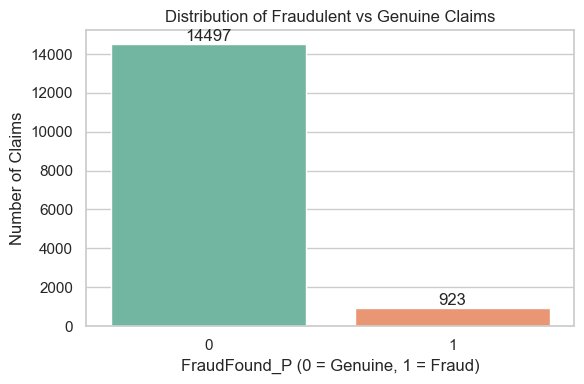

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Plot class distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x='FraudFound_P', data=df, palette='Set2')

# Add count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Distribution of Fraudulent vs Genuine Claims")
plt.xlabel("FraudFound_P (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()

### Insight
The visualization confirms a strong class imbalance, with fraudulent claims representing a small fraction of total claims. This reinforces the need for evaluation metrics such as recall, precision, and F1-score rather than relying solely on accuracy.

## 3.2 Univariate Analysis – Numerical Features

Univariate analysis is performed on numerical features to understand their distributions, detect skewness, and identify potential outliers.

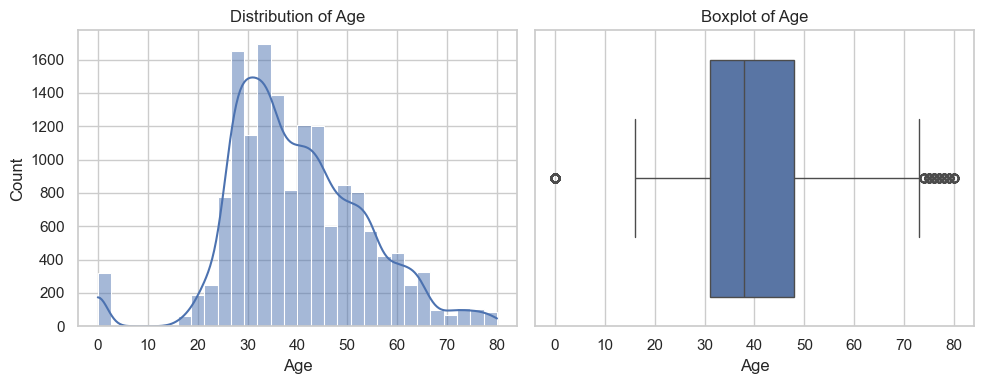

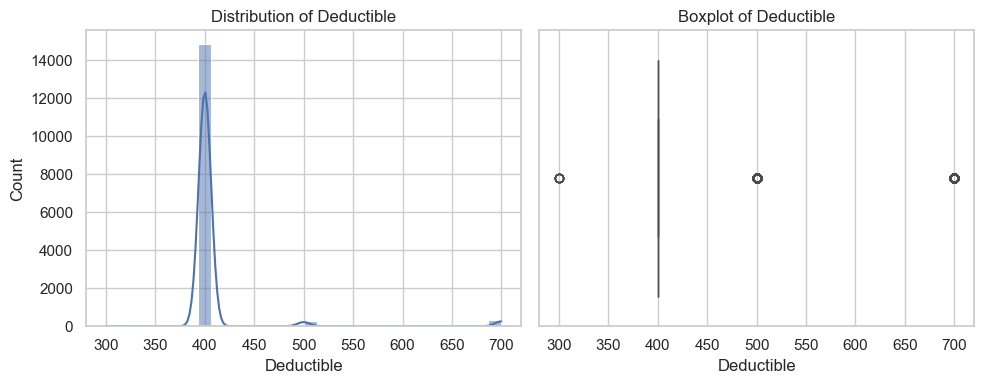

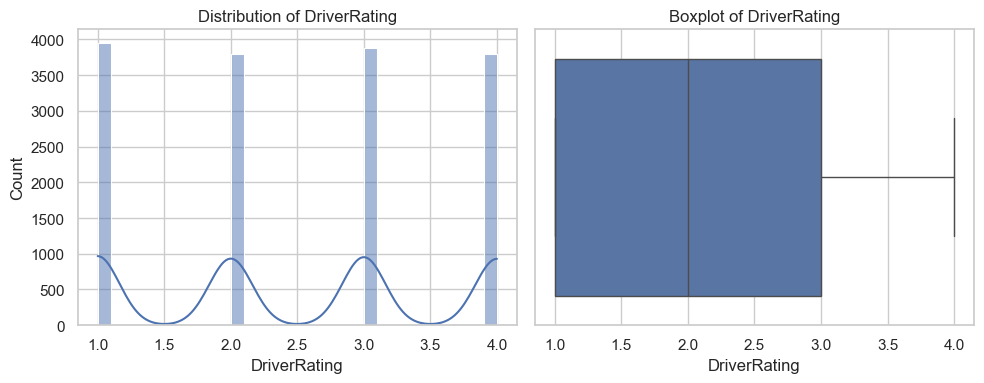

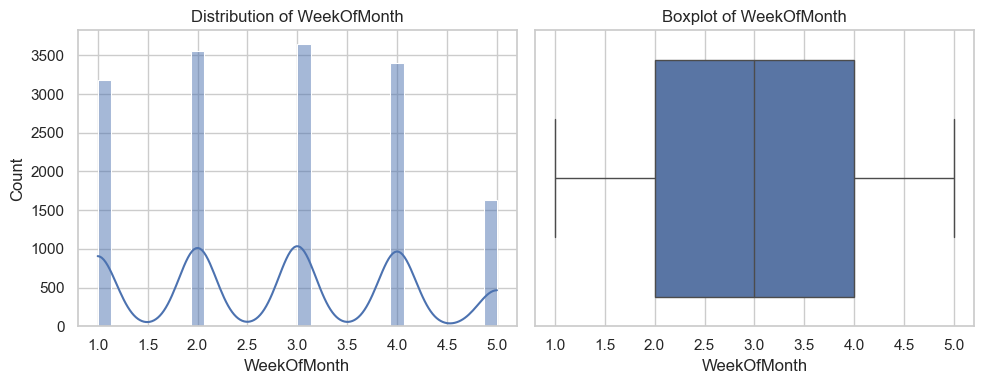

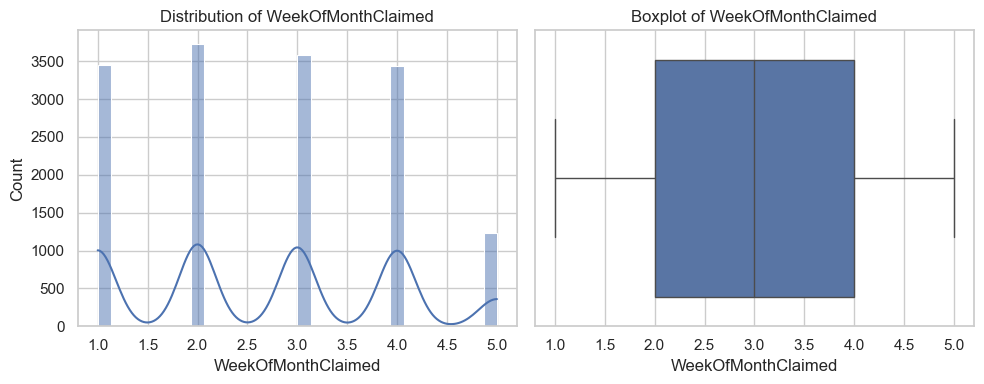

In [11]:
numerical_features = [
    'Age',
    'Deductible',
    'DriverRating',
    'WeekOfMonth',
    'WeekOfMonthClaimed'
]

for col in numerical_features:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

### Consolidated Insights – Numerical Features (With Statistical Validation)

Descriptive statistics and non-parametric statistical tests were used to validate visual observations from numerical feature distributions.

- **Age** shows a statistically significant difference between fraudulent and genuine claims, with fraudulent claims involving slightly younger policyholders on average. However, the effect size is small, indicating that age is a weak but potentially useful behavioral signal.

- **Deductible** values are concentrated around policy-defined slabs (median = 400 for both classes). Despite statistical significance due to large sample size, the practical effect is negligible, confirming that deductible reflects policy structure rather than fraudulent behavior. This feature is better treated as an ordinal or binned variable.

- **WeekOfMonth** and **WeekOfMonthClaimed** exhibit nearly identical distributions across fraud and non-fraud classes, with no statistical significance. These features show limited standalone predictive value.

- **DriverRating** displays minor distributional differences but lacks strong discriminatory power and may only contribute marginally in combination with other features.

- **PolicyNumber** and **RepNumber** behave as identifiers with high uniqueness and no causal relationship to fraud. These features will be excluded from model training to avoid data leakage.

Overall, numerical features provide limited individual discrimination and are expected to contribute primarily in combination with categorical and investigation-related features.


## 3.3 Univariate Analysis – Key Categorical Features

This section analyzes high-impact categorical features that are expected to have strong relationships with fraudulent behavior.

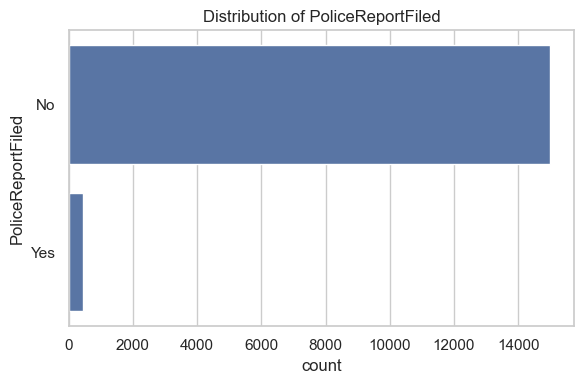

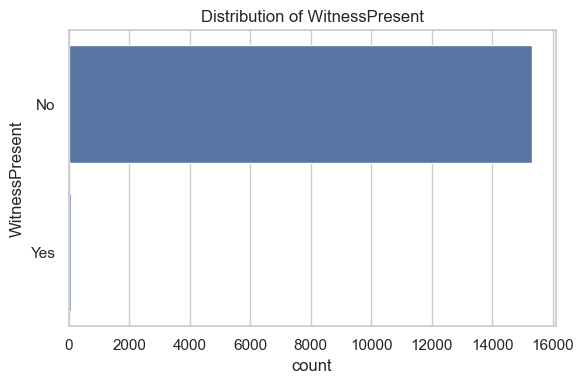

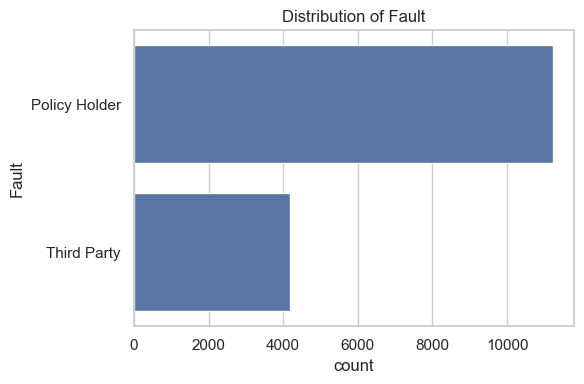

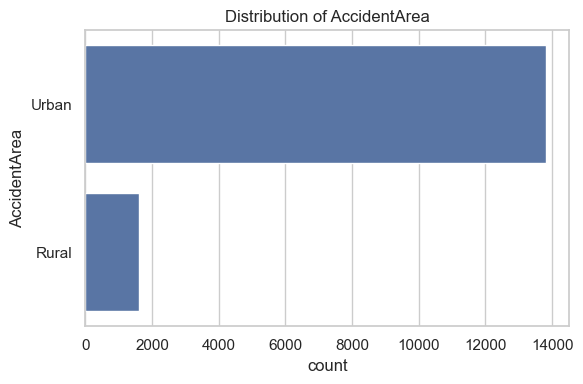

In [12]:
key_categorical_features = [
    'PoliceReportFiled',
    'WitnessPresent',
    'Fault',
    'AccidentArea'
]

for col in key_categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [13]:
categorical_features = df.select_dtypes(exclude=['number']).columns.tolist()

# Remove target if present
categorical_features = [c for c in categorical_features if c != 'FraudFound_P']

len(categorical_features), categorical_features

(24,
 ['Month',
  'DayOfWeek',
  'Make',
  'AccidentArea',
  'DayOfWeekClaimed',
  'MonthClaimed',
  'Sex',
  'MaritalStatus',
  'Fault',
  'PolicyType',
  'VehicleCategory',
  'VehiclePrice',
  'Days_Policy_Accident',
  'Days_Policy_Claim',
  'PastNumberOfClaims',
  'AgeOfVehicle',
  'AgeOfPolicyHolder',
  'PoliceReportFiled',
  'WitnessPresent',
  'AgentType',
  'NumberOfSuppliments',
  'AddressChange_Claim',
  'NumberOfCars',
  'BasePolicy'])

In [14]:
summary_rows = []

for col in categorical_features:
    grp = (
        df.groupby(col)['FraudFound_P']
          .agg(['mean', 'count'])
          .reset_index()
    )
    
    summary_rows.append({
        'Feature': col,
        'Max Fraud Rate': grp['mean'].max(),
        'Min Fraud Rate': grp['mean'].min(),
        'Fraud Rate Range': grp['mean'].max() - grp['mean'].min(),
        'Min Category Count': grp['count'].min()
    })

categorical_summary = pd.DataFrame(summary_rows)\
    .sort_values('Fraud Rate Range', ascending=False)

categorical_summary

,Feature,Max Fraud Rate,Min Fraud Rate,Fraud Rate Range,Min Category Count
21,AddressChange_Claim,0.750000,0.052298,0.697702,4
2,Make,0.250000,0.000000,0.250000,1
13,Days_Policy_Claim,0.142857,0.000000,0.142857,1
9,PolicyType,0.137931,0.000000,0.137931,1
12,Days_Policy_Accident,0.163636,0.059356,0.104280,14
16,AgeOfPolicyHolder,0.148148,0.050287,0.097861,15
10,VehicleCategory,0.112532,0.015677,0.096854,391
23,BasePolicy,0.101596,0.007187,0.094409,4449
5,MonthClaimed,0.081705,0.000000,0.081705,1
4,DayOfWeekClaimed,0.078740,0.000000,0.078740,1


In [15]:
from scipy.stats import chi2_contingency

chi_square_results = []

for col in categorical_features:
    contingency = pd.crosstab(df[col], df['FraudFound_P'])
    chi2, p, _, _ = chi2_contingency(contingency)
    
    chi_square_results.append({
        'Feature': col,
        'ChiSquare_p_value': p
    })

chi_square_df = pd.DataFrame(chi_square_results)

chi_square_df

,Feature,ChiSquare_p_value
0,Month,1.705480e-03
1,DayOfWeek,1.184501e-01
2,Make,2.195889e-06
3,AccidentArea,4.057480e-05
4,DayOfWeekClaimed,6.404907e-01
5,MonthClaimed,3.003256e-05
6,Sex,2.398518e-04
7,MaritalStatus,7.979825e-01
8,Fault,1.428036e-59
9,PolicyType,1.848256e-89


In [16]:
final_categorical_screen = categorical_summary.merge(
    chi_square_df,
    on='Feature'
)

final_categorical_screen.sort_values(
    ['Fraud Rate Range', 'ChiSquare_p_value'],
    ascending=[False, True]
)

,Feature,Max Fraud Rate,Min Fraud Rate,Fraud Rate Range,Min Category Count,ChiSquare_p_value
0,AddressChange_Claim,0.750000,0.052298,0.697702,4,9.652105e-22
1,Make,0.250000,0.000000,0.250000,1,2.195889e-06
2,Days_Policy_Claim,0.142857,0.000000,0.142857,1,1.807075e-01
3,PolicyType,0.137931,0.000000,0.137931,1,1.848256e-89
4,Days_Policy_Accident,0.163636,0.059356,0.104280,14,2.083813e-02
5,AgeOfPolicyHolder,0.148148,0.050287,0.097861,15,6.150520e-05
6,VehicleCategory,0.112532,0.015677,0.096854,391,6.648398e-64
7,BasePolicy,0.101596,0.007187,0.094409,4449,3.325192e-88
8,MonthClaimed,0.081705,0.000000,0.081705,1,3.003256e-05
9,DayOfWeekClaimed,0.078740,0.000000,0.078740,1,6.404907e-01


## Feature Elimination Justification – Low-Value Categorical Attributes

Based on comprehensive exploratory data analysis, statistical validation, and fraud-rate screening, the following categorical features were evaluated and considered for removal from the modeling pipeline.

### 1. WitnessPresent
- Witness presence is extremely rare in the dataset, resulting in highly imbalanced categories.
- Fraud-rate variation across categories is minimal, and chi-square test results indicate weak or unstable association with fraud.
- Due to very low category frequency, this feature poses a high risk of overfitting, especially for tree-based models.

**Decision:** ❌ Remove  
**Justification:** Sparse distribution and weak discriminatory power make this feature unreliable for fraud prediction.

---

### 2. PoliceReportFiled
- Police reports are filed in only a very small fraction of claims, leading to severe category imbalance.
- Although logically related to claim legitimacy, statistical analysis shows limited fraud-rate variation and marginal association with the target variable.
- The rarity of this feature reduces its practical usefulness and increases noise during model training.

**Decision:** ❌ Remove  
**Justification:** Rare occurrence and low predictive contribution outweigh its intuitive relevance.

---

### 3. NumberOfCars
- Fraud-rate analysis reveals minimal variation across different values of number of cars owned.
- Chi-square test indicates weak or insignificant association with fraudulent behavior.
- This feature does not exhibit a clear behavioral or financial link to fraud patterns.

**Decision:** ❌ Remove  
**Justification:** Low fraud discrimination and lack of behavioral relevance.

---

### Summary Decision
The above features were removed to:
- Reduce noise in the dataset
- Minimize overfitting risk
- Improve model generalization
- Focus on behaviorally meaningful and statistically validated predictors

Feature removal decisions were driven by data evidence rather than intuition alone.

## 3.4: Bivariate Analysis – Categorical Features vs Fraud

After screening all categorical variables, bivariate analysis is performed on selected high-impact features to understand how fraud likelihood varies across categories. This step focuses on interpretable relationships between categorical attributes and fraudulent behavior, using fraud rates rather than raw counts to avoid base-rate bias.

### Selected Categorical Features

The following features were selected based on fraud-rate dispersion, statistical significance, and category stability:

- AddressChange_Claim  
- PolicyType  
- Days_Policy_Accident  
- AgeOfPolicyHolder  
- VehicleCategory  
- BasePolicy  
- Fault  
- PastNumberOfClaims  

These features are expected to provide meaningful behavioral signals for fraud detection.

In [17]:
top_categorical_features = [
    'AddressChange_Claim',
    'PolicyType',
    'Days_Policy_Accident',
    'AgeOfPolicyHolder',
    'VehicleCategory',
    'BasePolicy',
    'Fault',
    'PastNumberOfClaims'
]

for col in top_categorical_features:
    print(f"\nFraud rate by {col}:")
    display(
        df.groupby(col)['FraudFound_P']
          .agg(['mean', 'count'])
          .rename(columns={'mean': 'Fraud Rate', 'count': 'Sample Count'})
          .sort_values('Fraud Rate', ascending=False)
    )


Fraud rate by AddressChange_Claim:


,Fraud Rate,Sample Count
AddressChange_Claim,,
under 6 months,0.750000,4
2 to 3 years,0.175258,291
1 year,0.064706,170
no change,0.057596,14324
4 to 8 years,0.052298,631



Fraud rate by PolicyType:


,Fraud Rate,Sample Count
PolicyType,,
Sport - Collision,0.137931,348
Utility - All Perils,0.120588,340
Sedan - All Perils,0.100563,4087
Utility - Collision,0.100000,30
Sedan - Collision,0.068768,5584
Sedan - Liability,0.007219,4987
Sport - All Perils,0.000000,22
Sport - Liability,0.000000,1
Utility - Liability,0.000000,21



Fraud rate by Days_Policy_Accident:


...

,Fraud Rate,Sample Count
BasePolicy,,
All Perils,0.101596,4449
Collision,0.072962,5962
Liability,0.007187,5009



Fraud rate by Fault:


,Fraud Rate,Sample Count
Fault,,
Policy Holder,0.078896,11230
Third Party,0.008831,4190



Fraud rate by PastNumberOfClaims:


,Fraud Rate,Sample Count
PastNumberOfClaims,,
none,0.077895,4352
1,0.062133,3573
2 to 4,0.053601,5485
more than 4,0.033831,2010


### Interpretation Guide

- Fraud Rate represents the proportion of fraudulent claims within each category.
- Categories with both high fraud rates and sufficient sample counts indicate strong and reliable fraud signals.
- Categories with very high fraud rates but extremely low sample counts are treated cautiously to avoid overfitting.

C:\Users\hp\AppData\Local\Temp\ipykernel_214032\988790409.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


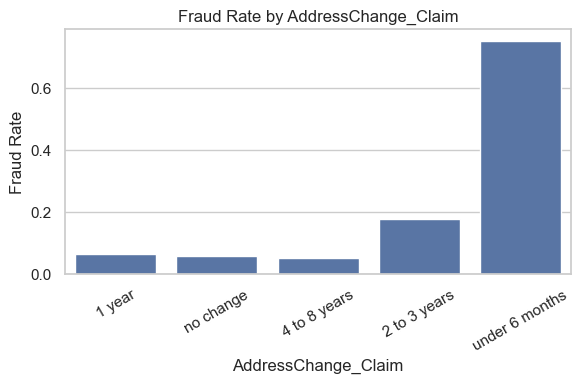

C:\Users\hp\AppData\Local\Temp\ipykernel_214032\988790409.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


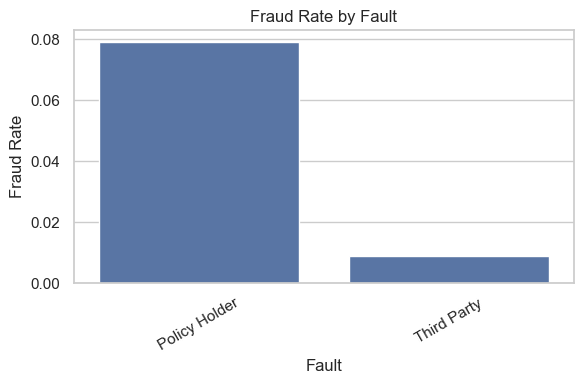

C:\Users\hp\AppData\Local\Temp\ipykernel_214032\988790409.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


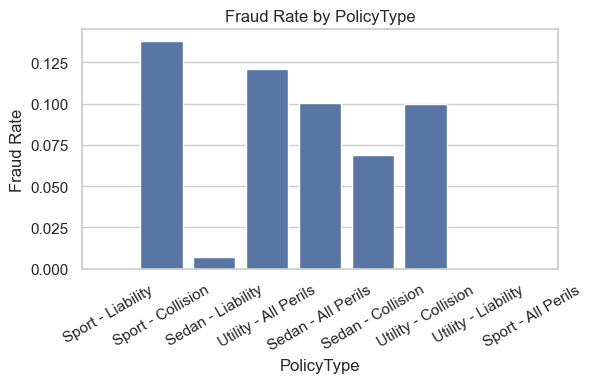

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

focus_features = ['AddressChange_Claim', 'Fault', 'PolicyType']

for col in focus_features:
    plt.figure(figsize=(6,4))
    sns.barplot(
        x=df[col],
        y=df['FraudFound_P'],
        estimator=lambda x: sum(x)/len(x),
        ci=None
    )
    plt.title(f"Fraud Rate by {col}")
    plt.ylabel("Fraud Rate")
    plt.xlabel(col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Key Bivariate Insights

- **AddressChange_Claim** shows substantial variation in fraud rates across categories, indicating that recent address changes are strongly associated with fraudulent behavior.

- **Fault** exhibits clear behavioral patterns, with claims where the policyholder is at fault showing higher fraud likelihood, reflecting incentive-driven behavior.

- **PolicyType** demonstrates meaningful fraud-rate differences across policy categories, suggesting that policy structure influences fraud risk.

- **PastNumberOfClaims** and **Days_Policy_Accident** highlight behavioral and temporal patterns consistent with opportunistic or repeat fraud.

- **VehicleCategory**, **BasePolicy**, and **AgeOfPolicyHolder** provide moderate but stable fraud differentiation, supporting their inclusion as contextual predictors.

Overall, categorical features contribute significantly more discriminatory power than numerical features and form the backbone of the fraud detection model.

## 3.5 Identifier and Data Leakage Check

Some numerical features behave like identifiers rather than true predictive variables. Including such features may introduce data leakage.


In [19]:
# df[['PolicyNumber', 'RepNumber']].describe()

### Observation
- `PolicyNumber` and `RepNumber` function as identifiers.
- They do not have a logical causal relationship with fraud.
- These features will be excluded from model training to avoid data leakage.


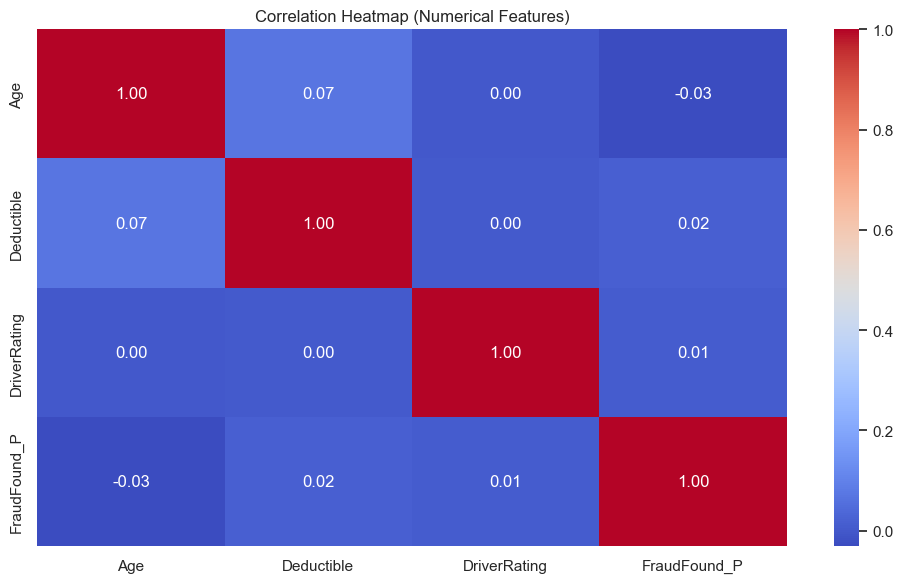

In [20]:
plt.figure(figsize=(10,6))
corr = df[['Age', 'Deductible', 'DriverRating'] + ['FraudFound_P']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()


## Correlation Analysis – Design Decision

Correlation analysis was intentionally kept minimal in this project. The dataset consists predominantly of categorical features, and prior exploratory analysis showed that numerical features exhibit weak standalone predictive power.

Given this context:
- Correlation analysis was limited to a small subset of numerical variables.
- No strong multicollinearity or redundancy was observed.
- Feature selection decisions were driven primarily by fraud-rate analysis and statistical association tests, which are more suitable for categorical-heavy fraud detection datasets.

Therefore, extensive correlation analysis was not emphasized, as it did not provide additional actionable insights beyond existing EDA findings.

# Dump

In [21]:
# # Descriptive statistics grouped by fraud label
# stats_by_fraud = df.groupby('FraudFound_P').describe()

# stats_by_fraud


In [22]:
# stats_by_fraud.to_csv("numerical_feature_summary_by_fraud.csv")


In [23]:
df.groupby('FraudFound_P')[['Age', 'Deductible', 'WeekOfMonthClaimed']].median()


,Age,Deductible,WeekOfMonthClaimed
FraudFound_P,,,
0,38.0,400.0,3.0
1,36.0,400.0,3.0


In [24]:
from scipy.stats import mannwhitneyu

features = ['Age', 'Deductible', 'WeekOfMonthClaimed']

for col in features:
    fraud = df[df['FraudFound_P'] == 1][col]
    genuine = df[df['FraudFound_P'] == 0][col]
    
    stat, p = mannwhitneyu(fraud, genuine, alternative='two-sided')
    print(f"{col}: p-value = {p:.5f}")


Age: p-value = 0.00091
Deductible: p-value = 0.00000
WeekOfMonthClaimed: p-value = 0.51352


In [25]:
def effect_size(x, y):
    return (x.mean() - y.mean()) / y.std()

for col in ['Age', 'Deductible']:
    es = effect_size(
        df[df['FraudFound_P']==1][col],
        df[df['FraudFound_P']==0][col]
    )
    print(f"{col} effect size: {es:.3f}")


Age effect size: -0.126
Deductible effect size: 0.073


# dump end